In [1]:
!pip install pandas
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 26.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 34.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.6 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 37.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]


In [51]:
import pandas as pd

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None)
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
print(df.columns)
df[4].value_counts()

Index([0, 1, 2, 3, 4], dtype='int64')


4
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [79]:
!pip install matplotlib
!pip install seaborn

# Features
A
B
C
D
AB
AC
AD
BC
BD
CD
ABC
ABD
ACD
BCD
ABCD

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

#Note to self: A = 0, B = 1, C = 2, D = 3 
#Result = 4

#Features: A, B, C, D, AB, AC, AD, BC, BD, CD, ABC, ABD, ACD, BCD, ABCD

#Total Features = 4
#Total Classes = 3 (3 possible results)

results = []                          #store it as a list for DataFrame conversion
features_combinations = {"A": [0],                        #all possible combinations (also to store combination via letters)
                         "B": [1],
                         "C": [2],
                         "D": [3], 
                         "AB": [0,1], 
                         "AC": [0,2],
                         "AD": [0,3],
                         "BC": [1,2],
                         "BD": [1,3],
                         "CD": [2,3],
                         "ABC": [0,1,2],
                         "ABD": [0,1,3],
                         "ACD": [0,2,3],
                         "BCD": [1,2,3],
                         "ABCD": [0,1,2,3]}

model = SGDClassifier(loss="hinge", random_state=1)            #Model. Setting a set state to ensure accuracy 

for combination, feature in features_combinations.items():        
  X = df[feature]          #inputs (double bracket to access each row)
  y = df[4]               #what we're trying to find (results)

  model.fit(X,y)

  predictions = model.predict(X)
  accuracy= accuracy_score(y, predictions)

  results.append({
    "Features": combination,
    "Accuracy": accuracy
  })

df_result = pd.DataFrame(results)                      #storing as DataFrame
df_result = df_result.sort_values(by="Accuracy")       #sorting from ascending

print(df_result)                       #print result

   Features  Accuracy
1         B  0.546667
4        AB  0.573333
0         A  0.640000
9        CD  0.666667
11      ABD  0.746667
14     ABCD  0.773333
13      BCD  0.853333
6        AD  0.873333
2         C  0.893333
8        BD  0.920000
5        AC  0.926667
10      ABC  0.933333
7        BC  0.940000
12      ACD  0.946667
3         D  0.960000


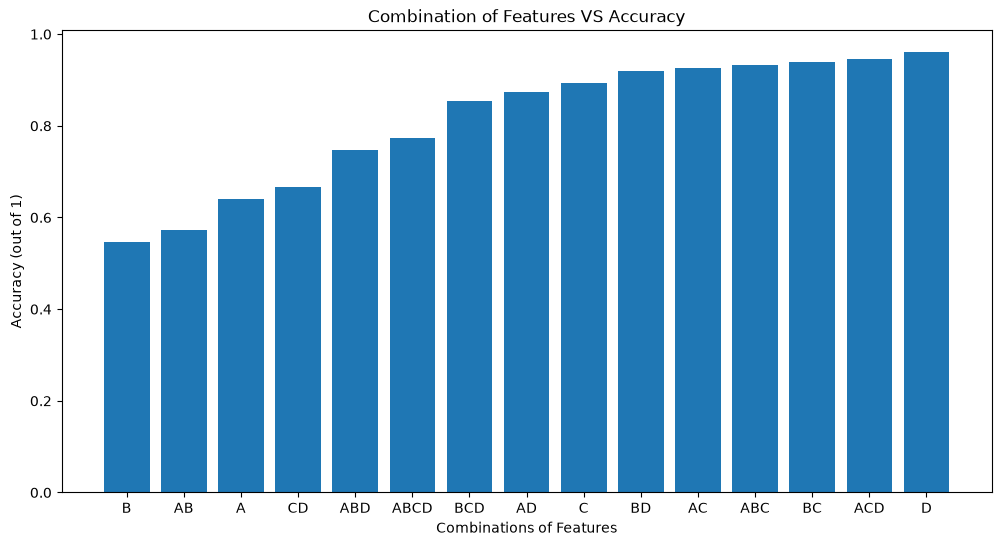

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))                                #size of bars
plt.bar(df_result["Features"], df_result["Accuracy"])     #plotting as bar graph

plt.xlabel("Combinations of Features")
plt.ylabel("Accuracy (out of 1)")
plt.title("Combination of Features VS Accuracy")
plt.show()

A- sepal length
B- sepal width
C- petal length
D- petal width

# Analysis

Feature D or the petal width seems to have the most accurate result when it is considered into our model. Then C causes the 2nd most accurate result when considered. However, A and B seems to have the lowest accuracy when considered into our model. This means that any combination of the features that contains A or B will drop the accuracy and any combinations with C or D will increase the accuracy (especially D as it is at the very top)

If you take a took at ACD and ABC accuracy, we can see that ACD's accuracy is higher than ACD due to D's feature being more accurate compared to C's feature. The same could be said about ACD and BCD since A's feature is higher than B's when by itself.

However, if we take a took at combination of features ABC, it is higher than the combination of ABD despite the difference of only C and D. From our previous hypothsis, since feature D by itself causes higher accuracy than feature C, we would assume combination ABD would have higher accuracy than ABC. But when you check the result, this is not the case (ABC= 0.92 and ABD= 0.78). Disproving the previous statement.

Another thing i realized is that just by increasing the number of features does not increase the total accuracy since ABCD only score around a 0.78 compared to D which was very accurate.